# Working with the V1DD functional metrics asset

This notebook shows how to load and query the per-ROI metrics table and
the three array archives that ship alongside it. See
[outputs.md](../outputs.md) for the full column reference.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# In Code Ocean the asset mounts at /data; locally, point to the results directory.
ASSET = Path("../../results/409828_V1DD_functional_metrics_2026-09-09_01-41-33")
assert ASSET.exists(), f"Asset not found at {ASSET}. Adjust the path for your environment."


## The per-ROI table

`stimulus_metrics.parquet` has one row per ROI (39,407 rows, 95 columns).
Nine identity columns, then metric blocks grouped by analysis family.


In [2]:
df = pd.read_parquet(ASSET / "stimulus_metrics.parquet")
print(f"{len(df):,} ROIs × {len(df.columns)} columns")
print(f"Sessions: {df.groupby(['column', 'volume']).ngroups}")
print(f"Planes: {df.groupby(['column', 'volume', 'plane']).ngroups}")
df[["roi_key", "column", "volume", "plane", "roi", "depth_um",
    "pika_roi_confidence", "snr", "dgw_osi", "dgw_dsi"]].head(10)


39,407 ROIs × 95 columns
Sessions: 25
Planes: 150


,roi_key,column,volume,plane,roi,depth_um,pika_roi_confidence,snr,dgw_osi,dgw_dsi
0,M409828_2_1_0_0,2,1,0,0,50.0,0.916531,2.066006,0.287317,0.473136
1,M409828_2_1_0_1,2,1,0,1,50.0,0.916861,4.994294,0.428314,0.171647
2,M409828_2_1_0_2,2,1,0,2,50.0,0.913705,1.512380,0.277535,0.670839
3,M409828_2_1_0_4,2,1,0,4,50.0,0.915848,1.650628,0.421001,0.301746
4,M409828_2_1_0_5,2,1,0,5,50.0,0.912224,1.182687,0.347188,0.067135
5,M409828_2_1_0_7,2,1,0,7,50.0,0.912520,1.292208,0.451771,0.261755
6,M409828_2_1_0_9,2,1,0,9,50.0,0.916683,1.335652,0.030123,0.162886
7,M409828_2_1_0_65,2,1,0,65,50.0,0.912281,1.573800,0.173638,0.089109
8,M409828_2_1_0_149,2,1,0,149,50.0,0.522310,1.475334,0.231562,0.193348
9,M409828_2_1_1_0,2,1,1,0,66.0,0.917007,6.757952,0.276826,0.371627


### Filtering by session

Join on `roi_key` or on `(column, volume, plane, roi)`.
`volume` is a string (values include hex digits in other datasets).


In [3]:
session = df[(df.column == 1) & (df.volume == "3")]
print(f"Column 1, Volume 3: {len(session):,} ROIs across {session.plane.nunique()} planes")
print(f"Depth range: {session.depth_um.min():.0f}–{session.depth_um.max():.0f} µm")
print(f"Median SNR: {session.snr.median():.1f}")
print(f"Median confidence: {session.pika_roi_confidence.median():.2f}")


Column 1, Volume 3: 2,708 ROIs across 6 planes
Depth range: 242–322 µm
Median SNR: 1.4
Median confidence: 0.92


## Tuning curves

`tuning_curves.npz` holds per-trial grating responses. The main arrays are
`dgw_trials` and `dgf_trials`, each (n_rois, 12 directions, 2 spatial frequencies, 8 trials).
Rows align with the parquet via `roi_key`.


In [4]:
tc = np.load(ASSET / "tuning_curves.npz", allow_pickle=True)
print("Arrays:", list(tc.files))
print(f"dgw_trials: {tc['dgw_trials'].shape}  (ROIs × dirs × SFs × trials)")
print(f"directions: {tc['directions']}")
print(f"spatial_frequencies: {tc['spatial_frequencies']}")


Arrays: ['roi_key', 'plane_key', 'directions', 'spatial_frequencies', 'trace_type', 'dgw_trials', 'dgw_blank', 'dgw_n_blank', 'dgw_params', 'dgw_running', 'dgf_trials', 'dgf_blank', 'dgf_n_blank', 'dgf_params', 'dgf_running']
dgw_trials: (39407, 12, 2, 8)  (ROIs × dirs × SFs × trials)
directions: [  0.  30.  60.  90. 120. 150. 180. 210. 240. 270. 300. 330.]
spatial_frequencies: [0.04 0.08]


In [ ]:
# Pick a well-tuned ROI: high OSI, high confidence
candidates = df[(df.dgw_osi > 0.8) & (df.pika_roi_confidence > 0.9) & (df.snr > 5)]
example = candidates.iloc[0]
idx = df.index.get_loc(example.name)
print(f"Example ROI: {example.roi_key}  (OSI={example.dgw_osi:.2f}, pref_dir={example.dgw_preferred_dir:.0f}°)")

# Trial-mean tuning curve at the preferred spatial frequency.
# dgw_preferred_sf is the SF value (0.04/0.08), not an index — map it to the SF axis.
sf_idx = int(np.argmin(np.abs(tc["spatial_frequencies"] - example.dgw_preferred_sf)))
trials = tc["dgw_trials"][idx, :, sf_idx, :]  # (12 dirs, 8 trials)
mean_resp = np.nanmean(trials, axis=1)
dirs_rad = np.deg2rad(tc["directions"])

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(4, 4))
ax.plot(np.append(dirs_rad, dirs_rad[0]), np.append(mean_resp, mean_resp[0]), "o-", lw=1.5)
ax.set_title(f"Direction tuning — {example.roi_key}\nOSI={example.dgw_osi:.2f}", fontsize=10, pad=12)
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
plt.tight_layout()
plt.show()

## Receptive field maps

`receptive_field_maps.npz` holds pre-threshold ON/OFF subfield maps
(n_rois, 2, 8 altitudes, 14 azimuths). Dimension 1: index 0 = ON, 1 = OFF.
Values are response fractions; the pipeline thresholds at 0.25 to set `has_rf_on`/`has_rf_off`.


rf_maps: (39407, 2, 8, 14)
altitudes: [-32.55 -23.25 -13.95  -4.65   4.65  13.95  23.25  32.55]
azimuths: [-60.45 -51.15 -41.85 -32.55 -23.25 -13.95  -4.65   4.65  13.95  23.25
  32.55  41.85  51.15  60.45]


C:\Users\bethanny.danskin\AppData\Local\Temp\ipykernel_30264\1337766390.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


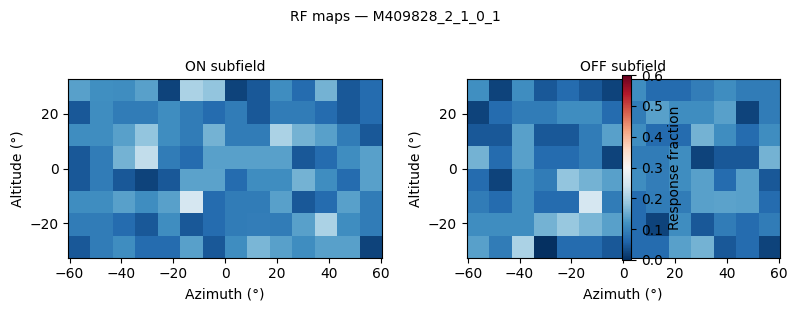

In [6]:
rf = np.load(ASSET / "receptive_field_maps.npz", allow_pickle=True)
print(f"rf_maps: {rf['rf_maps'].shape}")
print(f"altitudes: {rf['altitudes']}")
print(f"azimuths: {rf['azimuths']}")

# Pick a ROI with an ON receptive field
rf_rois = df[df.has_rf_on]
ex_rf = rf_rois.iloc[0]
rf_idx = df.index.get_loc(ex_rf.name)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, (ax, label) in enumerate(zip(axes, ["ON", "OFF"])):
    im = ax.imshow(rf["rf_maps"][rf_idx, i], aspect="auto", cmap="RdBu_r",
                   vmin=0, vmax=0.6, origin="lower",
                   extent=[rf["azimuths"][0], rf["azimuths"][-1],
                           rf["altitudes"][0], rf["altitudes"][-1]])
    ax.contour(rf["azimuths"], rf["altitudes"], rf["rf_maps"][rf_idx, i],
               levels=[0.25], colors="k", linewidths=0.8)
    ax.set_title(f"{label} subfield", fontsize=10)
    ax.set_xlabel("Azimuth (°)")
    ax.set_ylabel("Altitude (°)")
fig.colorbar(im, ax=axes, shrink=0.8, label="Response fraction")
fig.suptitle(f"RF maps — {ex_rf.roi_key}", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()


## Condition means (natural images)

`condition_means.npz` holds trial-averaged responses: `ni_mean` (n_rois, 118 images)
and `ni12_mean` (n_rois, 12 images). Every published natural-image column is a
reduction of these matrices.


ni_mean: (39407, 118)  (ROIs × 118 images)
ni12_mean: (39407, 12)  (ROIs × 12 images)


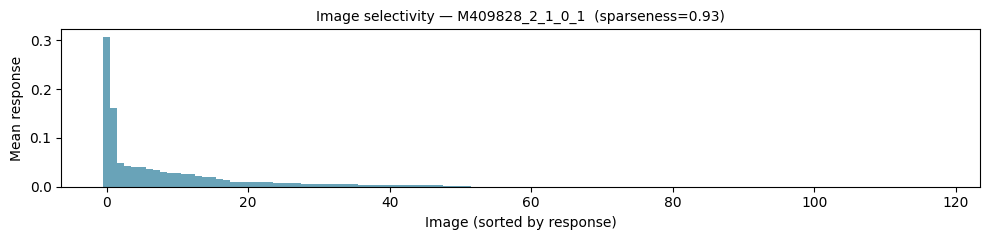

In [7]:
cm = np.load(ASSET / "condition_means.npz", allow_pickle=True)
print(f"ni_mean: {cm['ni_mean'].shape}  (ROIs × 118 images)")
print(f"ni12_mean: {cm['ni12_mean'].shape}  (ROIs × 12 images)")

# Show mean responses for a selective ROI
sparse_rois = df[df.ni_lifetime_sparseness > 0.9]
ex_ni = sparse_rois.iloc[0]
ni_idx = df.index.get_loc(ex_ni.name)

fig, ax = plt.subplots(figsize=(10, 2.5))
responses = cm["ni_mean"][ni_idx]
order = np.argsort(responses)[::-1]
ax.bar(range(118), responses[order], width=1, color="#2a7d9a", alpha=0.7)
ax.set_xlabel("Image (sorted by response)")
ax.set_ylabel("Mean response")
ax.set_title(f"Image selectivity — {ex_ni.roi_key}  (sparseness={ex_ni.ni_lifetime_sparseness:.2f})", fontsize=10)
plt.tight_layout()
plt.show()


## Provenance

`provenance.json` records the config, sessions processed, runtime breakdown,
and what differs from the reference configuration.


In [8]:
import json

with open(ASSET / "provenance.json") as f:
    prov = json.load(f)

print(f"Git SHA: {prov['git_sha']}")
print(f"Complete asset: {prov['complete_asset']}")
print(f"Wall time: {prov['wall_seconds'] / 3600:.2f} h")
print(f"Sessions: {len(prov['sessions'])}")
print(f"Failed: {prov['failed_sessions']}")
print(f"\nStage seconds (top 5):")
for stage, sec in sorted(prov["stage_seconds"].items(), key=lambda x: -x[1])[:5]:
    print(f"  {stage}: {sec:.0f}s ({sec/prov['wall_seconds']*100:.1f}%)")


Git SHA: 9f9af4ae0304ed8c0ab6aeb2d89212c79f96fa2f
Complete asset: True
Wall time: 5.15 h
Sessions: 25
Failed: []

Stage seconds (top 5):
  drifting_gratings_windowed: 6471s (34.9%)
  drifting_gratings_full: 6148s (33.2%)
  load_traces: 1332s (7.2%)
  natural_movie: 360s (1.9%)
  natural_images_12: 292s (1.6%)
